In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

In [2]:
x = 6 * np.random.rand(200, 1) - 3
y = 0.8 * x**2 + 0.9 * x + 2 + np.random.randn(200, 1)
# y = 0.8x^2 + 0.9x + 2

Text(0, 0.5, 'y')

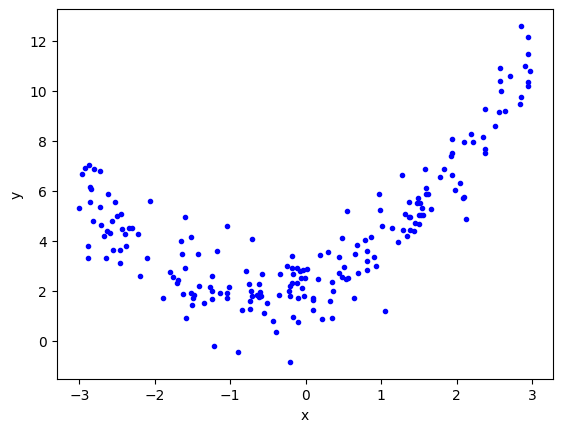

In [3]:
plt.plot(x,y,'b.')
plt.xlabel("x")
plt.ylabel("y")


In [4]:
# train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=2)

In [5]:
# applying linear regression
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [6]:
y_pred = lr.predict(x_test)
r2_score(y_test, y_pred)

0.22773391558807432

Text(0, 0.5, 'y')

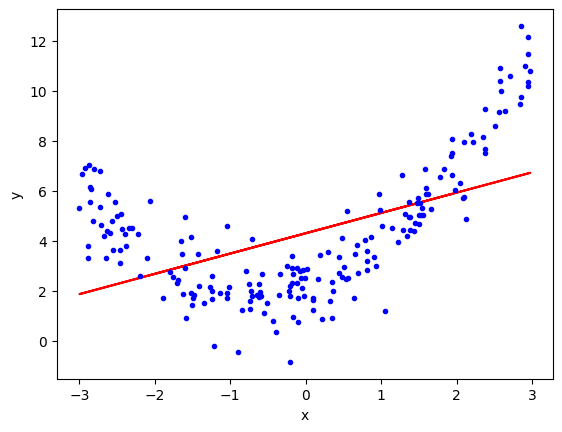

In [7]:
plt.plot(x_train, lr.predict(x_train), color='red')
plt.plot(x,y,"b.")
plt.xlabel("x")
plt.ylabel("y")

In [8]:
# applying polynomial linear regression
# degree 2 degree 2 means for every two columns in input you get 3 columns ex if input column is x then output column will be x^), x^1, x^2
poly = PolynomialFeatures(degree=2)
x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

In [9]:
print(x_train[0])
print(x_train_trans[0])

[1.92747416]
[1.         1.92747416 3.71515663]


In [10]:
# includes bias parameter

In [11]:
lr = LinearRegression()
lr.fit(x_train_trans, y_train)

LinearRegression()

In [12]:
y_pred = lr.predict(x_test_trans)

In [13]:
r2_score(y_test,y_pred)

0.9244973128068228

In [14]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.91482435 0.72326999]]
[2.18037486]


In [15]:
x_new = np.linspace(-3, 3, 100).reshape(100,1)
x_new_poly = poly.transform(x_new)
y_new = lr.predict(x_new_poly)

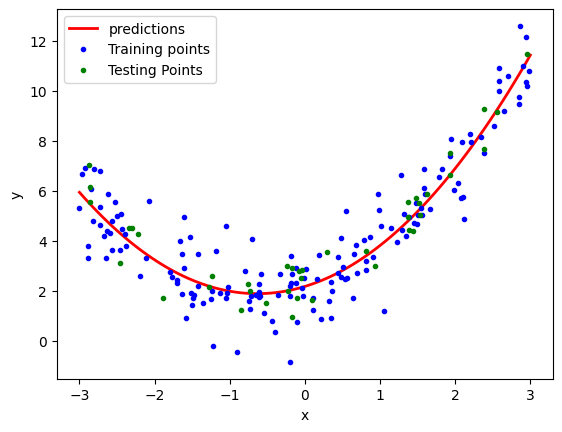

In [16]:
plt.plot(x_new, y_new, "r-", linewidth=2, label="predictions")
plt.plot(x_train, y_train, "b.", label="Training points")
plt.plot(x_test, y_test, "g.", label="Testing Points")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [17]:
def polynomial_regression(degree):
  x_new = np.linspace(-3, 3, 100).reshape(100, 1)
  x_new_poly = poly.transform(x_new)

  polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
  std_scaler = StandardScaler()
  lin_reg = LinearRegression()
  polynomial_regression = Pipeline([
          ("poly_features", polybig_features),
          ("std_scaler", std_scaler),
          ("lin_reg", lin_reg),
      ])
  polynomial_regression.fit(x,y)
  y_newbig = polynomial_regression.predict(x_new)
  plt.plot(x_new, y_newbig, 'r', label="Degree" + str(degree), linewidth=2)


  plt.plot(x_train, y_train, "b.", linewidth=3)
  plt.plot(x_test, y_test, "g.", linewidth=3)
  plt.legend(loc="upper left")
  plt.xlabel("x")
  plt.ylabel("y")
  plt.axis([-3, 3, 0, 10])
  plt.show()

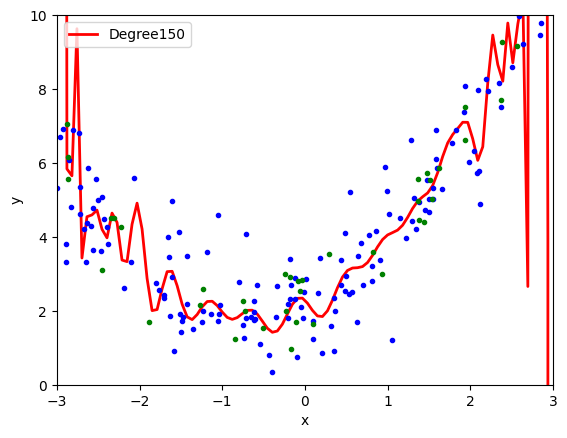

In [18]:
polynomial_regression(150)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


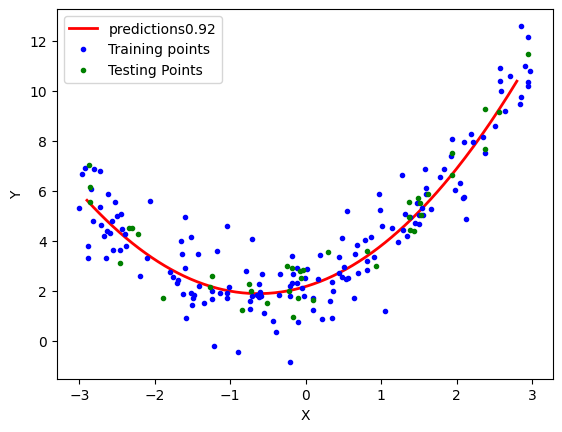

In [19]:
# Applying Gradient Descent

poly = PolynomialFeatures(degree=2)

x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

sgd = SGDRegressor(max_iter=100)
sgd.fit(x_train_trans, y_train)

x_new = np.linspace(-2.9, 2.8, 200).reshape(200, 1)
x_new_poly = poly.transform(x_new)
y_new = sgd.predict(x_new_poly)

y_pred = sgd.predict(x_test_trans)

plt.plot(x_new, y_new, "r-", linewidth=2, label="predictions" + str(round(r2_score(y_test, y_pred), 2)))
plt.plot(x_train, y_train, "b.", label="Training points")
plt.plot(x_test, y_test, "g.", label="Testing Points")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In [20]:
# 3D polynomial regression
x = 7 * np.random.rand(100,1) - 2.8
y = 7 * np.random.rand(100,1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.rand(100,1)

# z = x^2 + y^2 + 0.2x + 0.2y + 0.1*x*y + 2

In [21]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [22]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input, y_input)

final = np.vstack((xGrid.ravel().reshape(1,100), yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

In [23]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x=x_input, y=y_input, z=z_final))
fig.show()

In [24]:
x_multi = np.array([x,y]).reshape(100,2)
x_multi.shape

(100, 2)

In [25]:
poly = PolynomialFeatures(degree=2)
x_multi_trans = poly.fit_transform(x_multi)

In [26]:
print("INPUT", poly.n_features_in_)
print("OUTPUT", poly.n_output_features_)
print("Powers/n", poly.powers_)

INPUT 2
OUTPUT 6
Powers/n [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]]


In [27]:
x_multi_trans.shape

(100, 6)

In [28]:
lr = LinearRegression()
lr.fit(x_multi_trans, z)

LinearRegression()

In [29]:
x_test_multi = poly.transform(final)

In [30]:
z_final = lr.predict(x_multi_trans).reshape(10,10)

In [32]:
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.add_trace(go.Surface(x=x_input, y=y_input, z=z_final))
fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))
fig.show()